# Comparacion de Datos Numericos vs. Numericos

1. La correlacion
2. La matriz de correlacion
3. Los graficos de dispersion (scatter plots)
4. Los mapas hexagonales (hex binings) y los mapas de contorno o curvas de contorno (contour maps)

### 1. La correlacion

De manera simple:

> La correlacion mide el grado de relacion que hay entre dos variables numericas

Esta correlacion varia en el rango de -1 a 1:

- Si es cercana a -1 tenemos una relacion inversa entre las variables (si uno aumenta la otra disminuye)
- Si es cercana a 1 la relacion es directa (ambas variables cambian proporcionalmente)
- Si es cercana a 0 practicamente no existe relacion

### 📊 Diccionario de Datos (ETFs)

**🏛️ Índices de Mercado Principales y Estilos**

SPY (SPDR S&P 500 ETF Trust): Réplica el índice S&P 500. Representa el comportamiento de las 500 empresas de mayor capitalización en EE. UU. Es el principal termómetro del mercado de acciones.

QQQ (Invesco QQQ Trust): Réplica el índice Nasdaq 100. Está fuertemente ponderado hacia empresas de tecnología y crecimiento (Apple, Microsoft, Amazon, etc.).

DIA (SPDR Dow Jones Industrial Average ETF Trust): Réplica el índice Dow Jones. Mide el desempeño de 30 de las corporaciones industriales y estables más grandes de EE. UU.

IWM (iShares Russell 2000 ETF): Sigue a las empresas de pequeña capitalización (small-caps) en EE. UU. Es un excelente indicador de la salud económica interna del país.

**🛢️ Materias Primas y Volatilidad (Commodities & Risk)**

GLD (SPDR Gold Shares): Sigue el precio del oro físico. Es considerado un activo refugio en tiempos de incertidumbre o inflación.

USO (United States Oil Fund): Sigue el precio del petróleo crudo (WTI - West Texas Intermediate). Muy ligado al sector energético y factores geopolíticos.

VXX (iPath Series B S&P 500 VIX Short-Term Futures ETN): Sigue las expectativas de volatilidad a corto plazo del S&P 500 (conocido popularmente como el "índice del miedo"). Suele moverse de manera inversa al mercado de acciones.

**🏭 Sectores Económicos (SPDR Select Sectors & Others)**

XLK (Technology Select Sector): Sector de Tecnología de la Información (software, hardware, semiconductores).

XLF (Financial Select Sector): Sector Financiero (bancos principales como JPMorgan, aseguradoras y firmas de inversión).

XLV (Health Care Select Sector): Sector Salud (farmacéuticas, biotecnología y equipos médicos).

XLE (Energy Select Sector): Sector Energía (compañías de petróleo y gas como ExxonMobil o Chevron).

XLY (Consumer Discretionary Select Sector): Sector de Consumo Discrecional o Cíclico (bienes no esenciales: automóviles, lujo, comercio electrónico como Amazon, hoteles).

XLP (Consumer Staples Select Sector): Sector de Consumo Masivo o Básico (bienes esenciales: alimentos, supermercados, productos de higiene como Walmart o Coca-Cola). Es un sector defensivo.

XLU (Utilities Select Sector): Sector de Servicios Públicos (electricidad, agua, gas). Es otro sector típicamente defensivo que paga altos dividendos.

XLB (Materials Select Sector): Sector de Materiales Básicos (industria química, minería, metales, construcción).

XLI (Industrial Select Sector): Sector Industrial (maquinaria, aeroespacial, defensa, transporte y logística).

XTL (SPDR S&P Telecom ETF): Sector de Telecomunicaciones (redes, infraestructura de comunicación y servicios telefónicos).

In [1]:
import pandas as pd

etfs = pd.read_csv('../data/etfs-retornos-diarios.csv')
etfs

,XLI,QQQ,SPY,DIA,GLD,VXX,USO,IWM,XLE,XLY,XLU,XLB,XTL,XLV,XLP,XLF,XLK
0,-0.376098,0.096313,0.028223,-0.242796,0.419998,-10.400000,0.000000,0.534641,0.028186,0.095759,0.098311,-0.093713,0.019076,-0.009529,0.313499,0.018999,0.075668
1,0.376099,0.481576,0.874936,0.728405,0.490006,-3.520000,0.250000,0.926067,0.995942,0.000000,-0.044686,0.337373,0.000000,0.000000,0.129087,0.104492,0.236462
2,0.150440,0.096313,-0.103487,0.149420,0.239991,6.560000,-0.070000,-0.171848,-0.460387,0.306431,-0.151938,0.103086,0.019072,-0.142955,-0.073766,-0.142490,0.066211
3,-0.141040,-0.491201,0.018819,-0.205449,-0.519989,-8.800000,-0.180000,-0.229128,0.206706,0.153214,0.080437,0.018744,-0.429213,-0.095304,0.119865,0.066495,-0.227003
4,0.244465,-0.048160,-0.056445,-0.168094,0.429992,-0.480000,0.459999,-0.190939,-0.234892,-0.201098,-0.035751,-0.168687,0.000000,0.352630,-0.064548,0.018999,0.009457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749,-0.379997,-0.669998,-1.270004,-1.398679,0.010002,0.279999,-0.069999,-0.497896,-0.750000,-0.200005,-0.309997,-0.059997,-0.229999,0.189994,-0.279999,-0.220002,-0.330002
750,-0.040001,-0.700004,-0.389999,-0.079926,0.360001,-0.020001,0.189999,-0.587512,0.259995,-0.010002,0.340000,-0.290001,-0.280002,-0.220001,0.029998,-0.030001,-0.330002
751,-0.590000,-1.320000,-2.580002,-1.918189,0.260002,1.829999,-0.080000,-2.280327,-0.500000,-1.089996,-0.160000,-0.769996,-0.700001,-1.180000,-0.500000,-0.330000,-0.450000
752,-0.480000,-0.419998,-1.369996,-1.168887,0.130005,0.889999,0.139999,-0.338568,-0.169998,-0.430001,-0.310001,-0.270001,0.259999,-0.510002,-0.580002,-0.150002,-0.269996


In [2]:
etfs['QQQ'].corr(etfs['USO'])

np.float64(0.19949158785354248)

In [3]:
etfs['QQQ'].corr(etfs['XLK'])

np.float64(0.9451261579087488)

### La matriz de correlacion

In [4]:
etfs.info()

<class 'pandas.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   XLI     754 non-null    float64
 1   QQQ     754 non-null    float64
 2   SPY     754 non-null    float64
 3   DIA     754 non-null    float64
 4   GLD     754 non-null    float64
 5   VXX     754 non-null    float64
 6   USO     754 non-null    float64
 7   IWM     754 non-null    float64
 8   XLE     754 non-null    float64
 9   XLY     754 non-null    float64
 10  XLU     754 non-null    float64
 11  XLB     754 non-null    float64
 12  XTL     754 non-null    float64
 13  XLV     754 non-null    float64
 14  XLP     754 non-null    float64
 15  XLF     754 non-null    float64
 16  XLK     754 non-null    float64
dtypes: float64(17)
memory usage: 100.3 KB


In [5]:
etfs.corr()

,XLI,QQQ,SPY,DIA,GLD,VXX,USO,IWM,XLE,XLY,XLU,XLB,XTL,XLV,XLP,XLF,XLK
XLI,1.000000,0.785865,0.888865,0.869680,0.056554,-0.468196,0.236881,0.782380,0.650054,0.798080,0.380809,0.784144,0.374000,0.663022,0.600424,0.787340,0.777773
QQQ,0.785865,1.000000,0.908995,0.834440,0.043553,-0.470555,0.199492,0.810158,0.560044,0.839701,0.346667,0.713463,0.421790,0.775392,0.614806,0.752771,0.945126
SPY,0.888865,0.908995,1.000000,0.953726,0.078722,-0.547074,0.272069,0.833937,0.713300,0.887028,0.481928,0.826053,0.406181,0.811269,0.744466,0.883616,0.886588
DIA,0.869680,0.834440,0.953726,1.000000,0.051523,-0.511327,0.256793,0.758012,0.658311,0.847043,0.463364,0.787415,0.383928,0.771044,0.753725,0.860556,0.842757
GLD,0.056554,0.043553,0.078722,0.051523,1.000000,-0.107488,0.216563,0.070110,0.188625,0.017467,0.121611,0.184366,-0.042233,-0.010200,0.033047,0.043039,0.053022
VXX,-0.468196,-0.470555,-0.547074,-0.511327,-0.107488,1.000000,-0.195397,-0.448942,-0.448474,-0.474756,-0.260395,-0.470890,-0.205661,-0.380925,-0.416913,-0.514365,-0.477258
USO,0.236881,0.199492,0.272069,0.256793,0.216563,-0.195397,1.000000,0.249799,0.525943,0.183275,0.113182,0.324166,0.078796,0.119500,0.116857,0.221760,0.225962
IWM,0.782380,0.810158,0.833937,0.758012,0.070110,-0.448942,0.249799,1.000000,0.586991,0.779750,0.325003,0.701533,0.387274,0.664288,0.537065,0.756282,0.760438
XLE,0.650054,0.560044,0.713300,0.658311,0.188625,-0.448474,0.525943,0.586991,1.000000,0.578956,0.337942,0.689778,0.260463,0.454457,0.413486,0.599129,0.559324
XLY,0.798080,0.839701,0.887028,0.847043,0.017467,-0.474756,0.183275,0.779750,0.578956,1.000000,0.366827,0.721232,0.370299,0.702860,0.663055,0.782053,0.772189


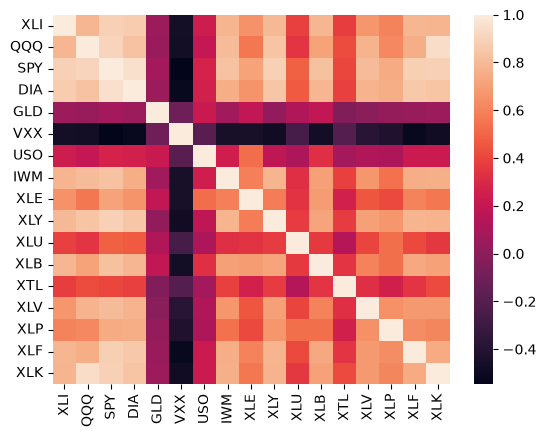

In [6]:
import seaborn as sns

sns.heatmap(etfs.corr());

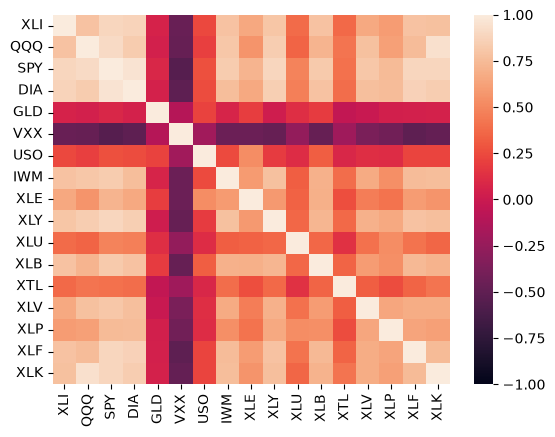

In [7]:
sns.heatmap(etfs.corr(), vmin=-1, vmax=1);

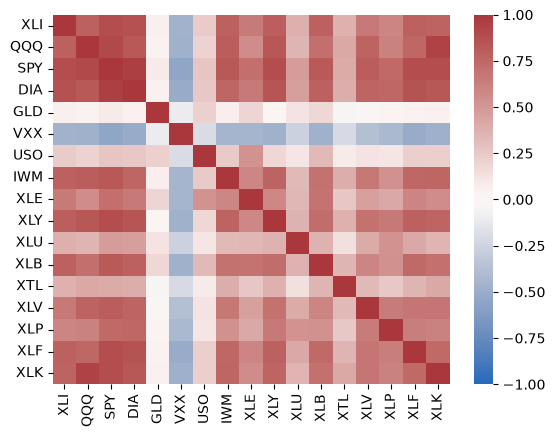

In [8]:
sns.heatmap(etfs.corr(), vmin=-1, vmax=1, cmap='vlag');

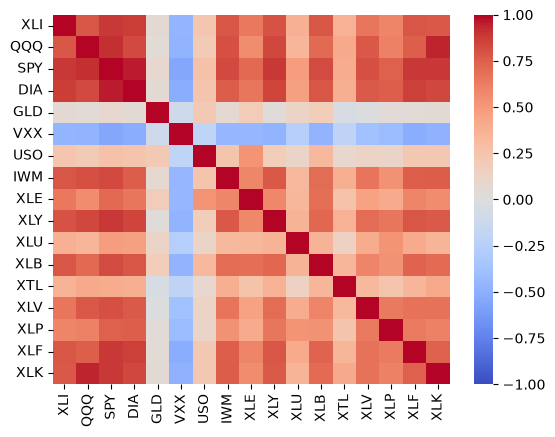

In [9]:
sns.heatmap(etfs.corr(), vmin=-1, vmax=1, cmap='coolwarm');

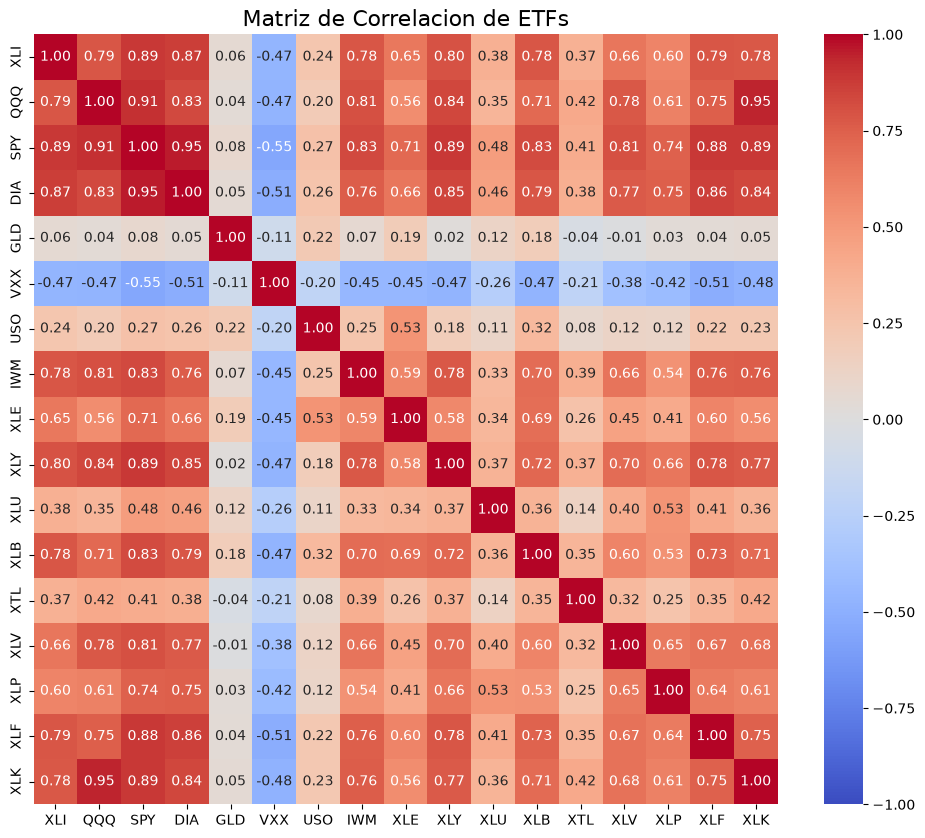

In [10]:
import matplotlib.pyplot as plt

# calcular la matriz de correlacion
correlacion_matriz = etfs.corr()

# configurar el tamaño del frafico
plt.figure(figsize=(12, 10))

# crear el mapa de calor con seaborn
sns.heatmap(correlacion_matriz, vmin=-1, vmax=1, cmap='coolwarm', annot=True, fmt='.2f')

# añadir titulo y etiquetas
plt.title("Matriz de Correlacion de ETFs", fontsize=16)

# mostrar el grafico
plt.show()

### 3. Los graficos de dispersion (scatter plot)

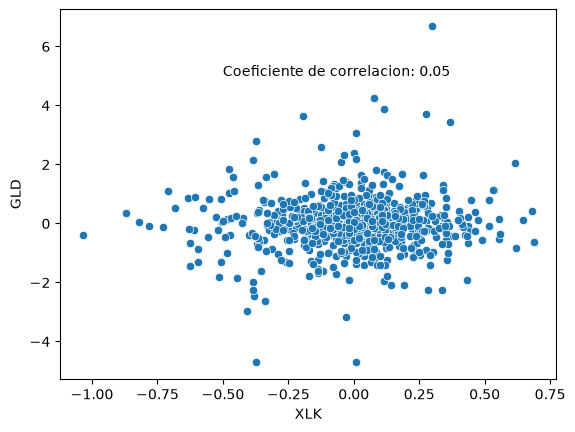

In [15]:
sns.scatterplot(data=etfs, x='XLK', y='GLD')
coef = etfs['XLK'].corr(etfs['GLD'])
plt.text(-0.5, 5, f'Coeficiente de correlacion: {coef:.2f}');

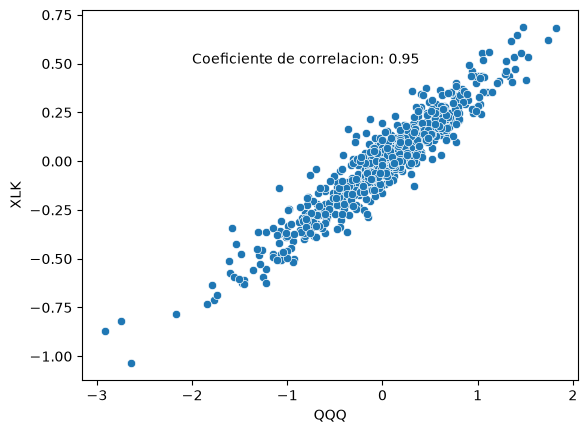

In [19]:
sns.scatterplot(data=etfs, x='QQQ', y='XLK')
coef = etfs['QQQ'].corr(etfs['XLK'])
plt.text(-2, 0.5, f'Coeficiente de correlacion: {coef:.2f}');

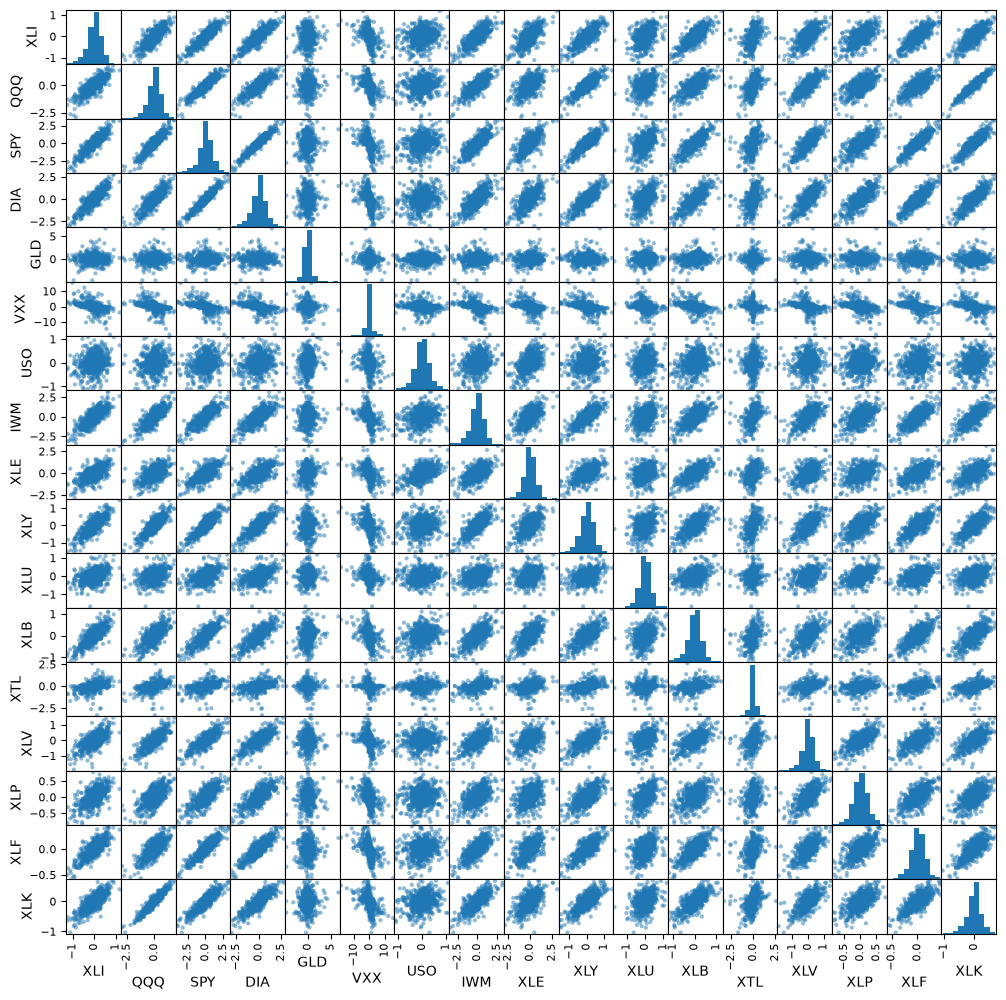

In [21]:
pd.plotting.scatter_matrix(etfs, figsize=(12, 12));